#  机器学习期末复习笔记：K-means 算法与严格数学证明

## 一、 核心概念与数学建模

### 1. 任务性质
K-means 属于 **无监督学习（Unsupervised Learning）** 中的 **聚类（Clustering）** 算法。其目标是在无标签的数据集 $\mathcal{D} = \{x_1, x_2, \dots, x_N\}$（其中 $x_n \in \mathbb{R}^D$）中，自动发现 $K$ 个潜在的几何结构簇。

### 2. 数学变量定义
* **簇中心（Centroids）**：记为 $\mu_k \in \mathbb{R}^D$，$k \in \{1, 2, \dots, K\}$。
* **分配变量（Assignments）**：记为 $z_n \in \{1, 2, \dots, K\}$，表示样本 $x_n$ 归属的簇标签。
* **指示函数（1-of-K 表示法）**：
    $$\mathbb{I}(z_n = k) = \begin{cases} 1, & \text{若 } z_n = k \\ 0, & \text{若 } z_n \neq k \end{cases}$$

### 3. 目标函数（畸变函数 / Distortion Function）
K-means 试图最小化所有样本点到其对应簇中心的欧氏距离平方和：
$$J(\mu, z) = \sum_{n=1}^N ||x_n - \mu_{z_n}||_2^2 = \sum_{k=1}^K \sum_{n=1}^N \mathbb{I}(z_n = k) ||x_n - \mu_k||_2^2$$

---

## 二、 优化算法：劳埃德算法（Lloyd's Algorithm）

由于目标函数同时包含离散变量 $z$ 和连续变量 $\mu$，属于非凸优化问题。算法采用**交替下降法（Alternating Descent）**策略：

1.  **初始化**：随机选择 $K$ 个点作为初始簇中心 $\mu^{(0)}$。
2.  **交替迭代**直至收敛：
    * **Step 1（更新分配 $z$）**：固定中心 $\mu$，将点分配给最近的中心。
        $$z_n^{(t)} = \arg\min_{k} ||x_n - \mu_k^{(t-1)}||_2^2$$
    * **Step 2（更新中心 $\mu$）**：固定分配 $z$，将中心移动到该簇内所有点的算术平均值处。
        $$\mu_k^{(t)} = \arg\min_{\mu_k} \sum_{n \in \mathcal{C}_k} ||x_n - \mu_k||_2^2$$

---

## 三、 核心定理与期末必考证明

### 定理 1：均值极值定理（簇中心的更新依据）
**【定理表述】**：在固定样本归属 $z$ 的条件下，使得局部目标函数 $J_k$ 最小的新中心 $\mu_k$ 由该簇内所有样本的算术平均值给出。

**【严格证明】（以一维空间 $D=1$ 为例）**
设簇 $\mathcal{C}_k$ 中的样本数量为 $N_k$，对应的局部目标函数为：
$$J_k(\mu_k) = \sum_{i \in \mathcal{C}_k} (x_i - \mu_k)^2$$

1.  **求一阶导数（寻找驻点）**：
    利用复合函数求导法则（链式法则）对未知数 $\mu_k$ 求偏导：
    $$\frac{\partial J_k}{\partial \mu_k} = \sum_{i \in \mathcal{C}_k} 2(x_i - \mu_k) \cdot (-1) = -2\sum_{i \in \mathcal{C}_k} x_i + 2\sum_{i \in \mathcal{C}_k} \mu_k$$
    因为 $\mu_k$ 相对于求和变量 $i$ 是常数，所以 $\sum_{i \in \mathcal{C}_k} \mu_k = N_k \mu_k$。带入得：
    $$\frac{\partial J_k}{\partial \mu_k} = -2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k$$
    令一阶导数为 $0$：
    $$-2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k = 0 \implies \mu_k^* = \frac{1}{N_k}\sum_{i \in \mathcal{C}_k} x_i$$

2.  **求二阶导数（验证极小值）**：
    $$\frac{\partial^2 J_k}{\partial \mu_k^2} = \frac{\partial}{\partial \mu_k}\left(-2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k\right) = 2N_k$$
    由于样本数 $N_k > 0$，故二阶导数恒大于 $0$。根据多元函数极值判别法，目标函数为严格凸函数，驻点 $\mu_k^*$ 必为全局极小值点。   *(证毕)* $\blacksquare$

---

### 定理 2：劳埃德算法的收敛性定理
**【定理表述】**：K-means 算法在有限步迭代内必然完全收敛。

**【严格证明】**
1.  **单调性**：
    * 在 Step 1 中，固定 $\mu^{(t-1)}$ 优化 $z^{(t)}$，因为 $z^{(t)}$ 是使距离最小的选择，故：$J(\mu^{(t-1)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t-1)})$。
    * 在 Step 2 中，固定 $z^{(t)}$ 优化 $\mu^{(t)}$，根据定理 1（均值是全局极小值），故：$J(\mu^{(t)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t)})$。
    * 串联得：$J(\mu^{(t)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t-1)})$，函数值**单调不增**。
2.  **有界性**：
    因为 $J(\mu, z)$ 是各项欧氏距离的平方和，天然满足下界 $J(\mu, z) \ge 0$。根据**单调收敛定理**，其实数序列函数值必收敛。
3.  **有限性**：
    每个数据点有 $K$ 种标签选择， $N$ 个点共有 $K^N$ 种有限的分配组合。在损失函数严格下降的驱动下，算法绝不会重复经过相同的状态空间。因此，算法必在有限步内令标签 $z$ 停止改变，达成完全收敛。 *(证毕)* $\blacksquare$

---

## 四、 算法局限性与工程策略（考点延伸）

1.  **局部极小值问题**：
    K-means 无法保证收敛到全局最优。
    * *应对策略*：多路随机初始化（Multi-start），或采用 **K-means++** 算法（使得初始簇中心彼此距离尽可能远）。
2.  **对离群点（Outliers）敏感**：
    由于目标函数内部采用平方损失（$L_2$ 范数），极端异常值会对均值计算产生巨大拉动。
3.  **超参数 $K$ 的选择（肘部法则 / Elbow Method）**：
    * 若 $K=N$，则目标函数 $J=0$，每个点自成一类，导致算法失去聚类和泛化价值（过拟合）。
    * *肘部法则*：绘制 $K$ 与 $J$（误差平方和）的曲线图。寻找曲线从“快速下降”转为“平缓下降”的拐点（即“肘部”），在该点，簇数量的边际收益达到了最佳平衡。

In [2]:
import torch

def kmeans_torch(X, K, max_iters=100, tol=1e-4):
    """
    使用 PyTorch 实现的 K-means (Lloyd's) 算法
    
    参数:
    X: torch.Tensor, 形状为 (N, D) 的数据矩阵
    K: int, 聚类簇的数量
    max_iters: int, 最大迭代次数
    tol: float, 收敛阈值（中心点改变量小于该值时提前停止）
    """
    N, D = X.shape
    
    # ==========================================
    # 0. 初始化: 随机选择 K 个数据点作为初始簇中心
    # ==========================================
    indices = torch.randperm(N)[:K]
    centroids = X[indices].clone()
    
    for row_iter in range(max_iters):
        # 备份旧的中心用于检查收敛
        old_centroids = centroids.clone()
        
        # =================================================================
        # 1. Step 1: 更新分配标签 z (固定 centroids, 优化 z)
        # =================================================================
        # 利用 PyTorch 的广播机制计算每个点到每个中心的欧氏距离平方
        # X 扩展为 (N, 1, D), centroids 扩展为 (1, K, D)
        # 减法后平方求和得到 (N, K) 的距离矩阵
        distances = torch.sum((X.unsqueeze(1) - centroids.unsqueeze(0)) ** 2, dim=2)
        
        # 沿簇中心维度(dim=1)寻找距离最近的中心的索引，即为分配标签 z
        z = torch.argmin(distances, dim=1)
        
        # =================================================================
        # 2. Step 2: 更新中心 \mu (固定 z, 优化 centroids)
        # =================================================================
        for k in range(K):
            # 筛选出当前属于第 k 个簇的所有数据点
            cluster_points = X[z == k]
            
            # 如果该簇不为空，则更新中心为这些点的算术平均值（均值定理）
            if len(cluster_points) > 0:
                centroids[k] = torch.mean(cluster_points, dim=0)
        
        # ==========================================
        # 3. 检查收敛性: 如果中心点几乎不再移动，提前结束
        # ==========================================
        centroid_shift = torch.sum((centroids - old_centroids) ** 2)
        if centroid_shift < tol:
            break
            
    return centroids, z

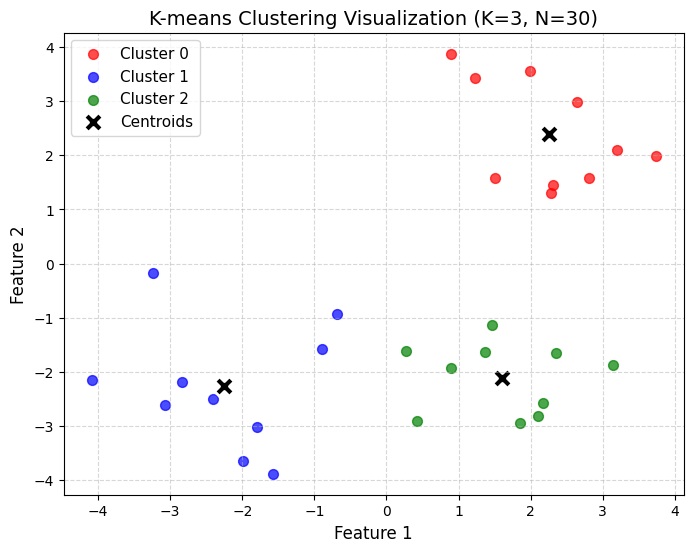

In [13]:
import torch
import matplotlib.pyplot as plt

# ==========================================
# 0. 数据准备 (30个二维数据点)
# # ==========================================
# torch.manual_seed(1)  # 固定随机种子以确保结果可复现

# 模拟生成3个不同中心的数据堆，每堆10个点，总共30个点
cluster1 = torch.randn(10, 2) + torch.tensor([2.0, 2.0])
cluster2 = torch.randn(10, 2) + torch.tensor([-2.0, -2.0])
cluster3 = torch.randn(10, 2) + torch.tensor([2.0, -2.0])

# 拼接成一个形状为 (30, 2) 的数据矩阵
X = torch.cat([cluster1, cluster2, cluster3], dim=0)

# ==========================================
# 1. 调用前面定义的 kmeans_torch 函数
# ==========================================
K = 3
# 提示：此处的 kmeans_torch 即为上一轮对话中编写的纯优化函数
centroids, z = kmeans_torch(X, K=K, max_iters=100)

# ==========================================
# 2. 使用 matplotlib 进行结果可视化
# ==========================================
plt.figure(figsize=(8, 6))

# 定义 3 个簇的颜色
colors = ['red', 'blue', 'green']

# 1. 绘制 30 个原始数据点，根据算法预测的标签 z 进行着色
for k in range(K):
    cluster_data = X[z == k]
    plt.scatter(cluster_data[:, 0].numpy(), cluster_data[:, 1].numpy(), 
                c=colors[k], label=f'Cluster {k}', s=50, alpha=0.7)

# 2. 绘制 K-means 算法最终收敛出的 3 个中心点 (Centroids)
plt.scatter(centroids[:, 0].numpy(), centroids[:, 1].numpy(), 
            c='black', marker='X', s=200, label='Centroids', edgecolors='white', linewidths=2)

# 美化图表
plt.title(f"K-means Clustering Visualization (K={K}, N={X.shape[0]})", fontsize=14)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# 显示图像
plt.show()

# 概率论基础与数理逻辑

## 一、 核心概念与概率法则

概率论是量化与处理机器学习中**不确定性（Uncertainty）** 的严谨数学框架。对于离散随机变量，其核心法则如下：

### 1. 联合概率分布 (Joint Probability Distribution)
设 $X$ 和 $Y$ 是两个离散随机变量，取值空间分别为 $X \in \{x_1, \dots, x_L\}$ 和 $Y \in \{y_1, \dots, y_M\}$。
联合概率 $p(X=x_i, Y=y_j)$ 表示事件 $X=x_i$ 与 $Y=y_j$ **同时发生**的概率。它必须满足以下两个基本性质：
* **非负性 (Non-negativity)**：$\forall x_i, y_j: p(X=x_i, Y=y_j) \ge 0$
* **归一化 (Normalization)**：$\sum_{i=1}^L \sum_{j=1}^M p(X=x_i, Y=y_j) = 1$

### 2. 边缘概率与求和法则 (The Sum Rule / Marginalization)
**【定义】**：通过穷举并消除联合概率分布中的一部分随机变量，从而得到全集在子集随机变量上的概率分布。
**【核心公式】**：
$$p(X=x_i) = \sum_{j=1}^M p(X=x_i, Y=y_j)$$

### 3. 条件概率与乘积法则 (Conditional Probability & Product Rule)
**【条件概率定义】**：在已知事件 $X=x_i$ 发生的前提下，观测到 $Y=y_j$ 发生的概率。
$$p(Y=y_j | X=x_i) = \frac{p(X=x_i, Y=y_j)}{p(X=x_i)}$$
**【乘积法则 (Product Rule)】**：将分母移项后得到，它允许我们将联合概率分布因式分解为条件概率与边缘概率的乘积：
$$p(X=x_i, Y=y_j) = p(Y=y_j | X=x_i) p(X=x_i) = p(X=x_i | Y=y_j) p(Y=y_j)$$
>  **链式拓展**：乘积法则可以链式推广到任意个随机变量的联合分布：
> $$p(X, Y, Z) = p(Z | X, Y) p(X | Y) p(Y)$$

### 4. 随机变量的独立性 (Independence)
**【定义】**：若两个随机变量 $X$ 和 $Y$ 相互独立（记作 $X \perp Y$），则它们的联合概率完全等于各自边缘概率的乘积：
$$X \perp Y \iff p(X, Y) = p(X) p(Y)$$
**【重要推论】**：若 $X \perp Y$，则条件概率等于边缘概率，即已知 $X$ 无法提供任何关于 $Y$ 的新信息：
$$p(Y | X) = \frac{p(Y, X)}{p(X)} = \frac{p(Y)p(X)}{p(X)} = p(Y)$$

---

## 二、 核心定理：贝叶斯定理 (Bayes' Theorem)

###  定理表述
贝叶斯定理源于乘积法则的对称性，它揭示了如何利用新观测到的数据（证据）去更新对某一事件的不确定性信念。
$$p(A | B) = \frac{p(B | A) p(A)}{p(B)} = \frac{p(B | A) p(A)}{\sum_{A'} p(B | A') p(A')}$$

###  数理统计学命名规范
在贝叶斯机器学习中，公式中的每一项都有严格的称呼：
* $p(A)$：**先验概率 (Prior)**。在观测到新数据 $B$ 之前，基于历史经验对事件 $A$ 建立的初始信任度。
* $p(B | A)$：**似然 (Likelihood)**。在假设事件 $A$ 成立的前提下，观测到数据 $B$ 的可能性大小。
* $p(B)$：**边缘似然 / 归一化常数 (Evidence / Marginal Likelihood)**。通常通过全概率公式（求和法则）展开，确保后验概率之和为 1。
* $p(A | B)$：**后验概率 (Posterior)**。结合了新数据 $B$ 之后，对事件 $A$ 做出的**修正后的概率信念**。

---

## 三、 经典考题：联合概率矩阵计算示例

针对以下联合概率分布表：

| 联合分布 $p(X, Y)$ | $y_1$ | $y_2$ | **边缘概率 $p(X)$** |
|:---:|:---:|:---:|:---:|
| **$x_1$** | $0.20$ | $0.10$ | **$0.30$** |
| **$x_2$** | $0.10$ | $0.10$ | **$0.20$** |
| **$x_3$** | $0.15$ | $0.35$ | **$0.50$** |
| **边缘概率 $p(Y)$** | **$0.45$** | **$0.55$** | **$1.00$** |

###  考点 1：条件概率计算
**【题目】**：求在已知 $X = x_3$ 的条件下，$Y = y_1$ 的概率 $p(Y=y_1 | X=x_3)$？
**【解析】**：
根据条件概率公式：
$$p(Y=y_1 | X=x_3) = \frac{p(X=x_3, Y=y_1)}{p(X=x_3)}$$
从表中读取数据：联合概率 $p(X=x_3, Y=y_1) = 0.15$，边缘概率 $p(X=x_3) = 0.50$。
$$p(Y=y_1 | X=x_3) = \frac{0.15}{0.50} = 0.30$$

---

###  考点 2：独立性严格判别
**【题目】**：判断该联合分布表中的随机变量 $X$ 与 $Y$ 是否相互独立？
**【解析】**：
若独立，则必须对任意组合均满足 $p(x_i, y_j) = p(x_i)p(y_j)$。我们任选一组进行校验，如 $(x_1, y_1)$：
* 从表中直接读取联合概率：$p(X=x_1, Y=y_1) = 0.20$
* 计算边缘概率的乘积：$p(X=x_1) \cdot p(Y=y_1) = 0.30 \times 0.45 = 0.135$
* 显而易见：
  $$0.20 \neq 0.135 \implies p(X=x_1, Y=y_1) \neq p(X=x_1)p(Y=y_1)$$
因存在不满足独立性定义的组合，故该表格中的随机变量 $X$ 和 $Y$ **不相互独立**。

# 贝叶斯定理与唤醒词检测器分析

## 一、 问题背景与变量建模

在评估现实世界中的稀有事件判定检测系统（如：语音唤醒词检测、医学筛查等）时，硬划分往往失效。我们需要通过概率论来量化判定中的不确定性。

### 1. 随机变量定义
在听到一段音频片段时，系统内部存在两个二进制离散随机变量：
* **真实状态 $X$**：$X \in \{0, 1\}$
  * $X = 1$：用户实际**说**了唤醒词。
  * $X = 0$：用户**没说**唤醒词（背景杂音）。
* **检测器判定 $Y$**：$Y \in \{0, 1\}$
  * $Y = 1$：检测器发出警报（判定为**阳性**）。
  * $Y = 0$：检测器保持静默（判定为**阴性**）。

### 2. 条件特征数据（已知输入）
* **先验概率 (Prior)**：唤醒词在生活中属于极罕见事件（基本比率极低）。
  $$p(X=1) = 0.0001 \quad \implies \quad p(X=0) = 1 - p(X=1) = 0.9999$$
* **真正率 (True Positive Rate / Recall / 灵敏度)**：
  $$p(Y=1 | X=1) = 0.99 \quad (99\%)$$
* **假正率 (False Positive Rate / 误报率)**：
  $$p(Y=1 | X=0) = 0.001 \quad (0.1\%)$$

---

## 二、 后验概率推导（贝叶斯全概率展开）

**【期末核心考点】**：当检测器突然发出警报（观测到 $Y=1$）时，用户实际上真的说了唤醒词的**后验概率 $p(X=1 | Y=1)$** 是多少？

### 1. 数学公式推导
根据贝叶斯定理，结合全概率公式对分母进行边缘化展开：
$$p(X=1 | Y=1) = \frac{p(Y=1 | X=1)p(X=1)}{p(Y=1)}$$
$$p(X=1 | Y=1) = \frac{p(Y=1 | X=1)p(X=1)}{p(Y=1 | X=1)p(X=1) + p(Y=1 | X=0)p(X=0)}$$

### 2. 数值代入计算
将已知数据代入公式的分子与分母各项：
* **分子（真阳性联合概率）**：
  $$p(Y=1, X=1) = 0.99 \times 0.0001 = 0.000099$$
* **分母（总报警概率 $p(Y=1)$）**：
  $$p(Y=1) = (0.99 \times 0.0001) + (0.001 \times 0.9999) = 0.000099 + 0.0009999 = 0.0010989$$

最终求得后验概率：
$$p(X=1 | Y=1) = \frac{0.000099}{0.0010989} \approx 0.0901 \implies \mathbf{9.01\%}$$

---

## 三、 底层数理本质：基本比率谬误 (Base Rate Fallacy)

### 1. 现象分析
计算结果表明，一个号称拥有 $99\%$ 捕捉率且只有 $0.1\%$ 误报率的高精度检测器，在实际发出警报时，**真正猜对的概率却只有 9.01%**。这意味着高达 90.99% 的报警全都是误报（假阳性）。

### 2. 底层数理原因
该现象在统计学上被称为**基本比率谬误**。
* 尽管假正率 $p(Y=1|X=0)$ 被控制得极低（$0.1\%$），但因为现实中没说唤醒词的基数（先验 $p(X=0)=99.99\%$）过于庞大。
* 巨大基数乘以微小概率，导致**误报的绝对数量**（$0.0009999$）远远超过了**真报警的绝对数量**（$0.000099$）。

---

## 四、 工业界工程破局策略

在产品设计中，9% 的准确率会导致严重的体验灾难。为了让后验概率 $p(X=1|Y=1)$ 达到工业级实用标准（如 $>90\%$），必须采取以下优化策略：

* **非核心方向**：盲目提升真正率（如将 $99\%$ 提高到 $99.9\%$），由于分子增量极小，对最终后验概率的提升微乎其微。
* **核心破局点（压低假正率）**：利用工程或算法手段将假正率 $p(Y=1|X=0)$ 从 $10^{-3}$（千分之一）强行压低两个数量级至 $10^{-5}$（十万分之一）。
* **优化后结果验证**：
  当 $p(Y=1|X=0) = 10^{-5}$ 时：
  $$p(X=1 | Y=1) \approx \frac{0.99 \times 0.0001}{(0.99 \times 0.0001) + (10^{-5} \times 0.9999)} \approx \frac{0.000099}{0.000099 + 0.00001} \approx \mathbf{90.8\%}$$
  系统的判定可信度瞬间跃升至 **90.8%**。

**【复习结论】**：在稀有事件（小先验）的检测和分类任务中，**系统的后验精度完全取决于对假正率（False Positive Rate）的控制**。